In [1]:
import pandas as pd
import numpy as np

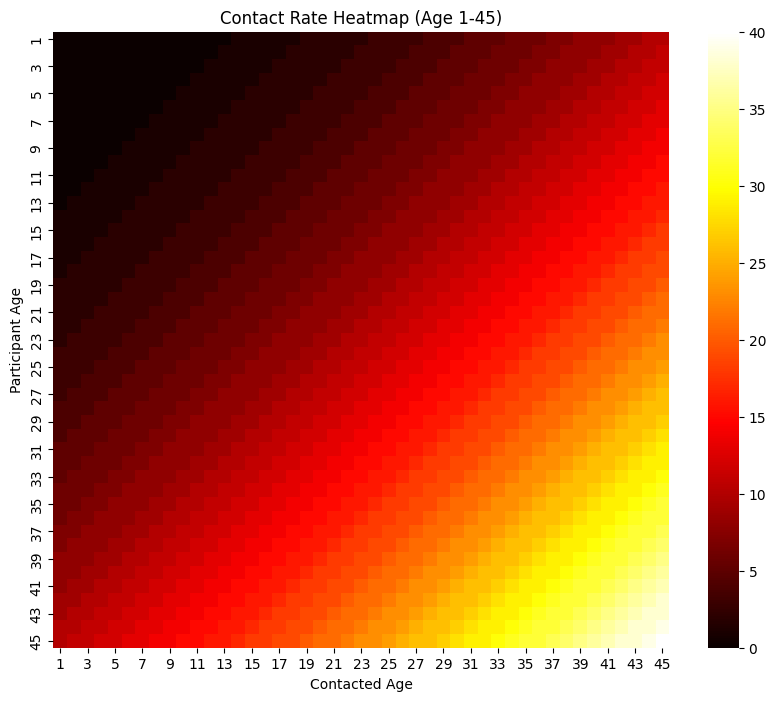

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Parameters
age_range = np.arange(1, 46)

# Create DataFrame for contact counts
data = []
for age_part in age_range:
    for age_cnt in age_range:
        # Define contact rate as a function of age sums (e.g., quadratic increase)
        contact_rate = (age_part + age_cnt) ** 2 // 199
        data.append([age_part, age_cnt, contact_rate])

contact_df = pd.DataFrame(data, columns=['age_part', 'age_cnt', 'y'])

# Pivot to create a heatmap matrix
heatmap_data = contact_df.pivot(index='age_part', columns='age_cnt', values='y')

# Plotting the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, cmap='hot', square=True)
plt.title("Contact Rate Heatmap (Age 1-45)")
plt.xlabel("Contacted Age")
plt.ylabel("Participant Age")
plt.show()


In [3]:
# True contact matrix

In [4]:
df = pd.DataFrame(data, columns=['age_part', 'age_cnt', 'y'])
df['id'] = np.arange(2025)

In [5]:
df['sex'] = df.id.apply(lambda x: str(x % 2))

In [6]:
df

,age_part,age_cnt,y,id,sex
0,1,1,0,0,0
1,1,2,0,1,1
2,1,3,0,2,0
3,1,4,0,3,1
4,1,5,0,4,0
...,...,...,...,...,...
2020,45,41,37,2020,0
2021,45,42,38,2021,1
2022,45,43,38,2022,0
2023,45,44,39,2023,1


In [7]:
np.random.seed(0)
for i in range(25):
    x = np.random.randint(200)
    df.loc[df.id==x, 'age_cnt'] = None

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2025 entries, 0 to 2024
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age_part  2025 non-null   int64  
 1   age_cnt   2002 non-null   float64
 2   y         2025 non-null   int64  
 3   id        2025 non-null   int64  
 4   sex       2025 non-null   object 
dtypes: float64(1), int64(3), object(1)
memory usage: 79.2+ KB


In [9]:
from cntmosaic.preprocess import impute_age_min_max, make_train_data

In [10]:
df

,age_part,age_cnt,y,id,sex
0,1,1.0,0,0,0
1,1,2.0,0,1,1
2,1,3.0,0,2,0
3,1,4.0,0,3,1
4,1,5.0,0,4,0
...,...,...,...,...,...
2020,45,41.0,37,2020,0
2021,45,42.0,38,2021,1
2022,45,43.0,38,2022,0
2023,45,44.0,39,2023,1


<Axes: xlabel='age_cnt', ylabel='age_part'>

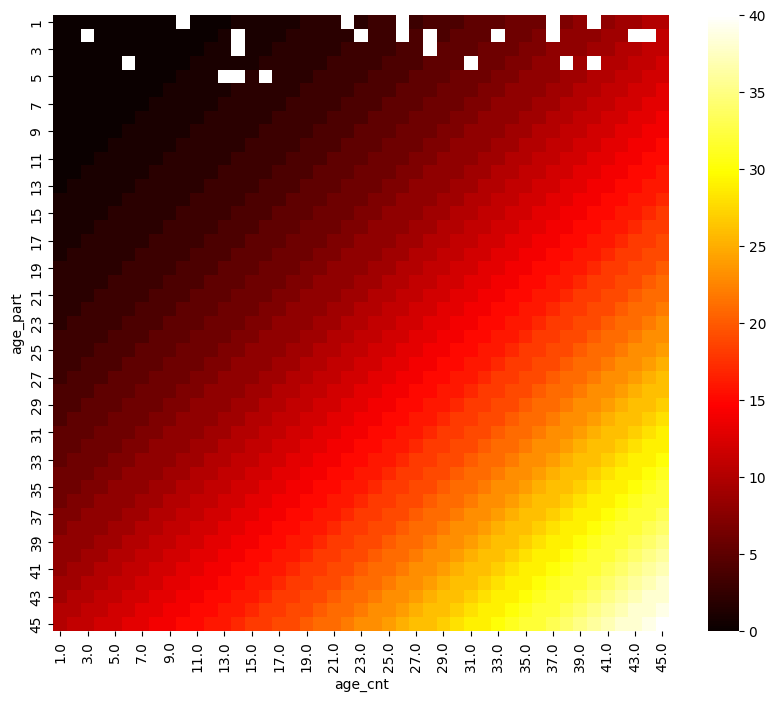

In [11]:
heatmap_data =df.dropna().pivot(index='age_part', columns='age_cnt', values='y')

# Plotting the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, cmap='hot', square=True)

In [12]:
df2 = make_train_data(df, 'id', grp_vars='sex')

/home/yiminglin/Downloads/cntmosaic-main/cntmosaic/preprocess/_preprocess.py:174: RuntimeWarning: Dropped 23 rows with missing values
  warnings.warn(f'Dropped {n_dropped} rows with missing values', RuntimeWarning)


In [13]:
df2

,age_part,age_cnt,sex,y,N
0,1,1,0,0,22
1,1,1,1,0,18
2,1,2,0,0,22
3,1,2,1,0,18
4,1,3,0,0,22
...,...,...,...,...,...
4045,45,43,1,0,22
4046,45,44,0,0,23
4047,45,44,1,39,22
4048,45,45,0,40,23


In [14]:
df['z'] = np.random.randint(10, size=2025)

In [15]:
from cntmosaic.preprocess import add_grp_cnt_offsets

df3 = add_grp_cnt_offsets(df2, df, 'sex')

In [16]:
df3

,age_part,age_cnt,sex,y,N,S
0,1,1,0,0,22,0.401163
1,1,1,1,0,18,0.409722
2,1,2,0,0,22,0.401163
3,1,2,1,0,18,0.409722
4,1,3,0,0,22,0.401163
...,...,...,...,...,...,...
4045,45,43,1,0,22,0.831731
4046,45,44,0,0,23,0.826484
4047,45,44,1,39,22,0.831731
4048,45,45,0,40,23,0.826484


In [17]:
from cntmosaic.models import BRCcustom

In [18]:
model = BRCcustom(df3, 1/ np.ones(45))

In [19]:
from numpyro import distributions as dist

In [20]:
model.add_prior('alpha', dist.InverseGamma(5, 5))

In [21]:
model.add_prior('nu', dist.InverseGamma(5, 5).expand([2]))

In [22]:
model.add_HSGP('alpha', 'nu')
model.add_prior('beta0', dist.Exponential(1))
model.add_intermediate('lograte=beta0+f')
model.add_intermediate('log_cint=lograte+log_P')

In [23]:
model.intermediate

{'lograte': 'beta0+f', 'log_cint': 'lograte+log_P'}

In [24]:
dist.InverseGamma(5, 5).expand([2]).__dict__

{'base_dist': <numpyro.distributions.continuous.InverseGamma at 0x75395c14b340>,
 '_expanded_sizes': OrderedDict([(-1, 2)]),
 '_interstitial_sizes': OrderedDict(),
 '_batch_shape': (2,),
 '_event_shape': ()}

In [25]:
model.set_age_dim(45)

In [26]:
import jax
model.compile()
model.run_inference_mcmc(jax.random.PRNGKey(0),
    num_samples = 50,
    num_warmup = 50,
    num_chains = 1)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

sample: 100%|██████████| 100/100 [02:43<00:00,  1.64s/it, 1023 steps of size 1.75e-03. acc. prob=0.62]


Number of divergences: 0


In [27]:
raise NameError

NameError: 

In [ ]:
from cntmosaic.sim import ModelEvaluatorMCMC

In [ ]:
me = ModelEvaluatorMCMC(model)

In [ ]:
me.get_posterior()

In [ ]:
me.get_post_cint()

In [ ]:
me.post_cint

In [ ]:
me.post.keys()

In [ ]:
len(me.post['log_cint'])

In [ ]:
me.diagnose()

In [ ]:
type(dist.NegativeBinomial2(1,1))

In [ ]:
name